In [ ]:
import pandas as pd
import numpy as np



In [ ]:
import matplotlib.pyplot as plt

In [ ]:
try:
    df_ocorrencias = pd.read_csv('03.BaseDPEvolucaoMensalCisp.csv', sep= ';', encoding='iso-8859-1')
    print(df_ocorrencias.info())
except Exception as e:
    print(f'Erro ao importar dados: {e}')


<class 'pandas.DataFrame'>
RangeIndex: 34848 entries, 0 to 34847
Data columns (total 63 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   cisp                        34848 non-null  int64  
 1   mes                         34848 non-null  int64  
 2   ano                         34848 non-null  int64  
 3   mes_ano                     34848 non-null  str    
 4   aisp                        34848 non-null  int64  
 5   risp                        34848 non-null  int64  
 6   munic                       34848 non-null  str    
 7   mcirc                       34848 non-null  int64  
 8   regiao                      34848 non-null  str    
 9   hom_doloso                  34848 non-null  int64  
 10  lesao_corp_morte            34848 non-null  int64  
 11  latrocinio                  34848 non-null  int64  
 12  cvli                        34848 non-null  int64  
 13  hom_por_interv_policial     34848 non-null

In [ ]:
try:
    df_dp = pd.read_csv('08.DP.csv', sep= ',', encoding='utf-8')
    print(df_dp.info())
except Exception as e:
    print(f'Erro ao importar dados: {e}')


<class 'pandas.DataFrame'>
RangeIndex: 137 entries, 0 to 136
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   codDP     137 non-null    int64
 1   nome      137 non-null    str  
 2   endereco  137 non-null    str  
dtypes: int64(1), str(2)
memory usage: 3.3 KB
None


In [ ]:
df_merge = df_ocorrencias.merge(df_dp, left_on='aisp', right_on='codDP', how='left')
df_roubos_celular = df_merge[['roubo_celular', 'nome', 'munic', "ano", "mes"]]

df_roubos_celular

,roubo_celular,nome,munic,ano,mes
0,32,005ª DP - Mem de Sá,Rio de Janeiro,2003,1
1,14,005ª DP - Mem de Sá,Rio de Janeiro,2003,1
2,34,005ª DP - Mem de Sá,Rio de Janeiro,2003,1
3,20,001ª DP - Praça da República,Rio de Janeiro,2003,1
4,1,001ª DP - Praça da República,Rio de Janeiro,2003,1
...,...,...,...,...,...
34843,0,035ª DP - Campo Grande,Cachoeiras de Macacu,2024,7
34844,0,033ª DP - Realengo,Mangaratiba,2024,7
34845,1,033ª DP - Realengo,Angra dos Reis,2024,7
34846,2,043ª DP - Guaratiba,Paraty,2024,7


In [ ]:
roubo_celular_array = np.array(df_roubos_celular["roubo_celular"])

q1_roubo_celular = np.quantile(roubo_celular_array, 0.25)
q2_roubo_celular = np.quantile(roubo_celular_array, 0.50)
q3_roubo_celular = np.quantile(roubo_celular_array, 0.75)

media_roubo_celular = np.mean(roubo_celular_array)
mediana_roubo_celular = np.median(roubo_celular_array)
moda_roubo_celular = df_roubos_celular["roubo_celular"].mode()

desvpad_roubo_celular = np.std(roubo_celular_array)
varincia_roubo_celular = np.var(roubo_celular_array) 
cv_roubo_celular = desvpad_roubo_celular/media_roubo_celular
delta_roubo_celular = media_roubo_celular/q2_roubo_celular

assimetria_roubo_celular = df_roubos_celular["roubo_celular"].skew()
curtose_roubo_celular = df_roubos_celular["roubo_celular"].kurtosis()

iqr_roubo_celular = q3_roubo_celular - q1_roubo_celular
lim_inf_roubo_celular = q1_roubo_celular - 1.5 * iqr_roubo_celular
lim_sup_roubo_celular = q3_roubo_celular + 1.5 * iqr_roubo_celular

df_roubos_celular_outliers_inf = df_roubos_celular[df_roubos_celular['roubo_celular'] < lim_inf_roubo_celular]

df_roubos_celular_outliers_sup = df_roubos_celular[df_roubos_celular['roubo_celular'] > lim_sup_roubo_celular]


In [ ]:
print(f'1. Média: {media_roubo_celular}')
print(f'2. Mediana: {q2_roubo_celular}')
print(f'3. Moda: {moda_roubo_celular}')

print(f'4. Desvio Padrão: {desvpad_roubo_celular}')
print(f'5. Variância: {varincia_roubo_celular}')
print(f'6. Coeficiente de Variação: {cv_roubo_celular*100:.2f}%')
print(f'7. Delta Média/Mediana: {delta_roubo_celular:,.2f}')

print(f'8. Assimetria é igual a : {assimetria_roubo_celular}')
print(f'9. Curtose é igual a: {curtose_roubo_celular}')

print(f'10. Limite Inferior de Roubo de Celular: {lim_inf_roubo_celular}')
print(f'11. Limite Superior de Roubo de Celular: {lim_sup_roubo_celular}')


1. Média: 7.967487373737374
2. Mediana: 2.0
3. Moda: 0    0
Name: roubo_celular, dtype: int64
4. Desvio Padrão: 13.518525112302813
5. Variância: 182.7505212119618
6. Coeficiente de Variação: 169.67%
7. Delta Média/Mediana: 3.98
8. Assimetria é igual a : 3.3718925483694226
9. Curtose é igual a: 18.800643806052463
10. Limite Inferior de Roubo de Celular: -16.5
11. Limite Superior de Roubo de Celular: 27.5


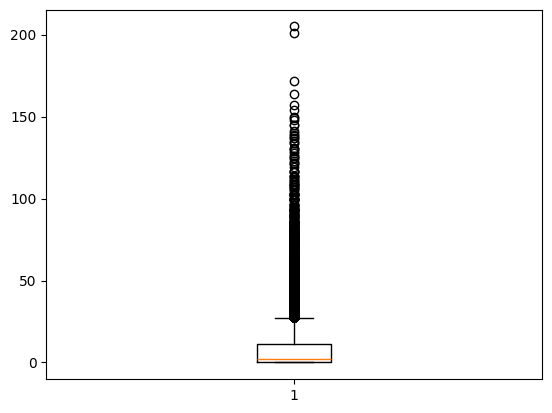

In [ ]:
plt.boxplot(roubo_celular_array, vert=True, showfliers=True)
plt.show()

Observações:

   1. Não há outliers inferiores, uma vez que o Limite Inferior de Roubo de Celulares é negativo.
   2. No entanto, há muitos outliers superiores. 

    Próximo passo é pesquisar os outliers superiores. Ou seja, quais regiões (DPs), em quais meses tiveram maiores incidência de roubos de celulares. Far-se-á isso em duas partes. Na primeira, listaremos as DPs que tiveram mais quantidade de registros de roubos de celulares em um dado mês. Para isso, listaremos as 20 com maior ocorrência desse tipo de roubo.

    Na sequência, listar-se-á as top 3 DPs de cada mês. Para tanto, será agregado a quantidade de registros de roubos de celulares por mês, somando os diferentes anos de janeiro, os diferentes anos de fevereiro e assim sucessivamente.


In [ ]:
df_roubo_celulares_agrupado = df_roubos_celular[['mes', "nome", "roubo_celular"]].groupby("roubo_celular").sum().reset_index().sort_values(by="roubo_celular", ascending=False)
df_roubo_celulares_agrupado

,roubo_celular,mes,nome
142,205,10,015ª DP - Gávea
141,201,2,005ª DP - Mem de Sá
140,172,9,015ª DP - Gávea
139,164,11,015ª DP - Gávea
138,157,12,015ª DP - Gávea
...,...,...,...
4,4,6834,020ª DP - Vila Isabel034ª DP - Bangu007ª DP - ...
3,3,8797,020ª DP - Vila Isabel015ª DP - Gávea034ª DP - ...
2,2,10793,024ª DP - Piedade020ª DP - Vila Isabel034ª DP ...
1,1,19880,001ª DP - Praça da República014ª DP - Leblon02...


In [ ]:
df_roubo_celulares_agrupado.nlargest(20, 'roubo_celular')

,roubo_celular,mes,nome
142,205,10,015ª DP - Gávea
141,201,2,005ª DP - Mem de Sá
140,172,9,015ª DP - Gávea
139,164,11,015ª DP - Gávea
138,157,12,015ª DP - Gávea
137,154,6,015ª DP - Gávea
136,150,7,039ª DP - Pavuna
135,149,8,015ª DP - Gávea
134,148,3,039ª DP - Pavuna
133,145,13,015ª DP - Gávea015ª DP - Gávea


Como se pode visualizar do dataframe supra, as DPs da Gávea, Mem de Sá, Pavuna e Bonsucesso se destacam em número elevado de registros de roubo de celulares, em meses específicos.

Na sequência, agregar-se-á os meses do período de análise, entre 2003 e 2024, e se estudará, no acumulado de cada mês, quais DPs são destaque no top 3 do somatório de cada mês.

In [ ]:
df_roubo_celulares_agrupado = df_roubos_celular.groupby(["mes", "nome"], as_index=False)["roubo_celular"].sum()
df_roubo_celulares_agrupado

,mes,nome,roubo_celular
0,1,001ª DP - Praça da República,114
1,1,004ª DP - Praça da República,493
2,1,005ª DP - Mem de Sá,1193
3,1,006ª DP - Cidade Nova,949
4,1,007ª DP - Santa Teresa,1169
...,...,...,...
452,12,037ª DP - Ilha do Governador,19
453,12,038ª DP - Brás de Pina,12
454,12,039ª DP - Pavuna,512
455,12,040ª DP - Honório Gurgel,408


In [ ]:
df_top3_roubo_celular_mes = df_roubo_celulares_agrupado.groupby("mes").apply(lambda x: x.nlargest(3,"roubo_celular")).reset_index()
df_top3_roubo_celular_mes

,mes,level_1,nome,roubo_celular
0,1,16,020ª DP - Vila Isabel,2110
1,1,5,009ª DP - Catete,1775
2,1,11,015ª DP - Gávea,1598
3,2,54,020ª DP - Vila Isabel,1899
4,2,43,009ª DP - Catete,1605
5,2,40,005ª DP - Mem de Sá,1538
6,3,92,020ª DP - Vila Isabel,2177
7,3,81,009ª DP - Catete,1918
8,3,78,005ª DP - Mem de Sá,1469
9,4,130,020ª DP - Vila Isabel,2333


As DPs da Gávea, Mem de Sá, Catete e Vila Isabel são os destaques, ao agregar os meses e calcular o top 3 do somatório de registro de roubos de celular para cada mês.

Desse modo, ao juntar ambas as formas de análise, destacam-se as DPs da Gávea e Mem de Sá. Com ressalvas importantes para Pavuna, Bonsucesso, Vila Isabel e Catete. Por conseguinte, são regiões cujo valor do seguro deve ser majorado, dado o maior risco desses locais, uma vez que possuem elevado número de registros de roubos de celular.

In [ ]:
df_merge = df_ocorrencias.merge(df_dp, left_on='aisp', right_on='codDP', how='left')
df_roubos_transeunte = df_merge[['roubo_transeunte', 'nome', 'munic', 'ano', 'mes']]

df_roubos_transeunte


,roubo_transeunte,nome,munic,ano,mes
0,26,005ª DP - Mem de Sá,Rio de Janeiro,2003,1
1,25,005ª DP - Mem de Sá,Rio de Janeiro,2003,1
2,26,005ª DP - Mem de Sá,Rio de Janeiro,2003,1
3,14,001ª DP - Praça da República,Rio de Janeiro,2003,1
4,4,001ª DP - Praça da República,Rio de Janeiro,2003,1
...,...,...,...,...,...
34843,1,035ª DP - Campo Grande,Cachoeiras de Macacu,2024,7
34844,0,033ª DP - Realengo,Mangaratiba,2024,7
34845,2,033ª DP - Realengo,Angra dos Reis,2024,7
34846,2,043ª DP - Guaratiba,Paraty,2024,7


In [ ]:
roubo_transeunte_array = np.array(df_roubos_transeunte["roubo_transeunte"])

q1_roubo_transeunte = np.quantile(roubo_transeunte_array, 0.25)
q2_roubo_transeunte = np.quantile(roubo_transeunte_array, 0.50)
q3_roubo_transeunte = np.quantile(roubo_transeunte_array, 0.75)

media_roubo_transeunte = np.mean(roubo_transeunte_array)
mediana_roubo_transeunte = np.median(roubo_transeunte_array)
moda_roubo_transeunte = df_roubos_transeunte["roubo_transeunte"].mode()

desvpad_roubo_transeunte = np.std(roubo_transeunte_array)
varincia_roubo_transeunte = np.var(roubo_transeunte_array) 
cv_roubo_transeunte = desvpad_roubo_transeunte/media_roubo_transeunte
delta_roubo_transeunte = media_roubo_transeunte/q2_roubo_transeunte

assimetria_roubo_transeunte = df_roubos_transeunte["roubo_transeunte"].skew()
curtose_roubo_transeunte = df_roubos_transeunte["roubo_transeunte"].kurtosis()

iqr_roubo_transeunte = q3_roubo_transeunte - q1_roubo_transeunte
lim_inf_roubo_transeunte = q1_roubo_transeunte- 1.5 * iqr_roubo_transeunte
lim_sup_roubo_transeunte = q3_roubo_transeunte + 1.5 * iqr_roubo_transeunte

df_roubos_transeunte_outliers_inf = df_roubos_transeunte[df_roubos_transeunte['roubo_transeunte'] < lim_inf_roubo_transeunte]

df_roubos_transeunte_outliers_sup = df_roubos_transeunte[df_roubos_transeunte['roubo_transeunte'] > lim_sup_roubo_transeunte]


In [ ]:
print(f'1. Média: {media_roubo_transeunte}')
print(f'2. Mediana: {q2_roubo_transeunte}')
print(f'3. Moda: {moda_roubo_transeunte}')

print(f'4. Desvio Padrão: {desvpad_roubo_transeunte}')
print(f'5. Variância: {varincia_roubo_transeunte}')
print(f'6. Coeficiente de Variação: {cv_roubo_transeunte*100:.2f}%')
print(f'7. Delta Média/Mediana: {delta_roubo_transeunte:,.2f}')

print(f'8. Assimetria é igual a : {assimetria_roubo_transeunte}')
print(f'9. Curtose é igual a: {curtose_roubo_transeunte}')

print(f'10. Limite Inferior de Roubo de Celular: {lim_inf_roubo_transeunte}')
print(f'11. Limite Superior de Roubo de Celular: {lim_sup_roubo_transeunte}')


1. Média: 34.93847566574839
2. Mediana: 11.0
3. Moda: 0    0
Name: roubo_transeunte, dtype: int64
4. Desvio Padrão: 51.00564777123664
5. Variância: 2601.576104563457
6. Coeficiente de Variação: 145.99%
7. Delta Média/Mediana: 3.18
8. Assimetria é igual a : 2.369312135564573
9. Curtose é igual a: 7.7882420571846325
10. Limite Inferior de Roubo de Celular: -79.5
11. Limite Superior de Roubo de Celular: 132.5


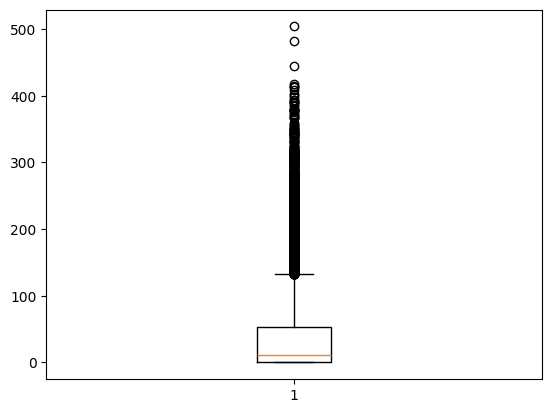

In [ ]:
plt.boxplot(roubo_transeunte_array, vert=True, showfliers=True)
plt.show()

Observações:

   1. A análise é similar a vista ao analisar os roubos de celular.
   2. Não há outliers inferiores, uma vez que o Limite Inferior de roubo a transeuntes é negativo.
   3. No entanto, há muitos outliers superiores. 

    Próximo passo é pesquisar os outliers superiores. Ou seja, quais regiões (DPs), em quais meses tiveram maiores incidência de roubos a transeuntes. Far-se-á isso em duas partes. Na primeira, listaremos as DPs que tiveram mais quantidade de registros de roubos a transeuntes em um dado mês. Para isso, listaremos as 20 com maior ocorrência desse tipo de roubo.

    Na sequência, listar-se-á as top 3 DPs de cada mês. Para tanto, será agregado a quantidade de registros de roubos a transeuntes por mês, somando os diferentes anos de janeiro, os diferentes anos de fevereiro e assim sucessivamente.


In [ ]:
df_roubo_transeunte_agrupado = df_roubos_transeunte[['mes', "nome", "roubo_transeunte"]].groupby("roubo_transeunte").sum().reset_index().sort_values(by="roubo_transeunte", ascending=False)
df_roubo_transeunte_agrupado

,roubo_transeunte,mes,nome
369,504,10,021ª DP - Bonsucesso
368,482,5,021ª DP - Bonsucesso
367,444,1,015ª DP - Gávea
366,417,8,021ª DP - Bonsucesso
365,414,8,015ª DP - Gávea
...,...,...,...
4,4,4614,001ª DP - Praça da República020ª DP - Vila Isa...
3,3,6210,007ª DP - Santa Teresa012ª DP - Copacabana028ª...
2,2,8875,010ª DP - Botafogo010ª DP - Botafogo035ª DP - ...
1,1,17265,024ª DP - Piedade015ª DP - Gávea034ª DP - Bang...


In [ ]:
df_roubo_transeunte_agrupado.nlargest(20, 'roubo_transeunte')

,roubo_transeunte,mes,nome
369,504,10,021ª DP - Bonsucesso
368,482,5,021ª DP - Bonsucesso
367,444,1,015ª DP - Gávea
366,417,8,021ª DP - Bonsucesso
365,414,8,015ª DP - Gávea
364,413,16,021ª DP - Bonsucesso015ª DP - Gávea
363,409,7,015ª DP - Gávea
362,402,8,014ª DP - Leblon
361,401,6,014ª DP - Leblon
360,398,5,015ª DP - Gávea


Como se pode visualizar do dataframe supra, as DPs da Bonsucesso, Gávea, Santa Teresa e Leblon se destacam em número elevado de registros de roubo de celulares, em meses específicos.

Na sequência, agregar-se-á os meses do período de análise, entre 2003 e 2024, e se estudará, no acumulado de cada mês, quais DPs são destaque no top 3 do somatório de cada mês.

In [ ]:
df_roubo_transeunte_agrupado = df_roubos_transeunte.groupby(["mes", "nome"], as_index=False)["roubo_transeunte"].sum()
df_roubo_transeunte_agrupado

,mes,nome,roubo_transeunte
0,1,001ª DP - Praça da República,548
1,1,004ª DP - Praça da República,2301
2,1,005ª DP - Mem de Sá,4639
3,1,006ª DP - Cidade Nova,3341
4,1,007ª DP - Santa Teresa,8673
...,...,...,...
452,12,037ª DP - Ilha do Governador,182
453,12,038ª DP - Brás de Pina,55
454,12,039ª DP - Pavuna,2668
455,12,040ª DP - Honório Gurgel,1682


In [ ]:
df_top3_roubo_transeunte_mes = df_roubo_transeunte_agrupado.groupby("mes").apply(lambda x: x.nlargest(3,"roubo_transeunte")).reset_index()
df_top3_roubo_transeunte_mes

,mes,level_1,nome,roubo_transeunte
0,1,16,020ª DP - Vila Isabel,9029
1,1,4,007ª DP - Santa Teresa,8673
2,1,5,009ª DP - Catete,8249
3,2,54,020ª DP - Vila Isabel,8473
4,2,43,009ª DP - Catete,8111
5,2,42,007ª DP - Santa Teresa,7647
6,3,81,009ª DP - Catete,9124
7,3,92,020ª DP - Vila Isabel,9099
8,3,80,007ª DP - Santa Teresa,8422
9,4,130,020ª DP - Vila Isabel,9473


As DPs de Vila Isabel, Santa Teresa, Catete comandam todos os top 3 de todos os meses do ano, ao agregar os meses e calcular o top 3 do somatório de registro de roubos a transeuntes para cada mês.

Desse modo, ao juntar ambas as formas de análise, destaca-se a DP de Santa Teresa, única presente em ambas as análises a roubos de transeuntes. Com ressalvas importantes para Bonsucesso, Gávea, Catete e Vila Isabel. Por conseguinte, são regiões cujo valor do seguro deve ser majorado, dado o maior risco desses locais, uma vez que possuem elevado número de registros de roubos a transeuntes.

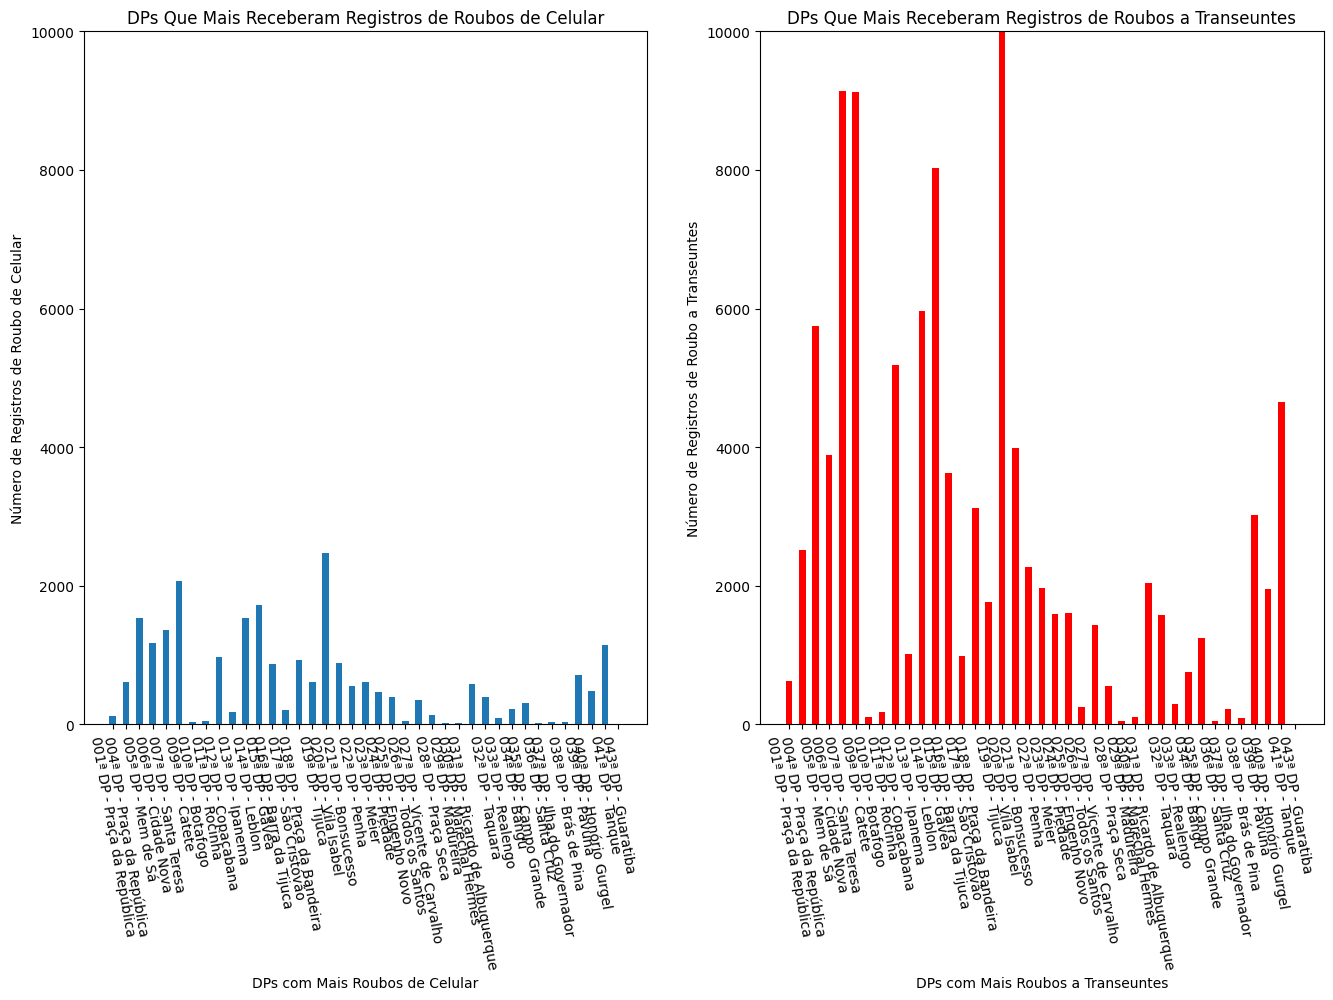

In [ ]:
plt.figure(figsize=(16, 9))

plt.subplot(1, 2, 1)
plt.bar(df_roubo_celulares_agrupado["nome"],df_roubo_celulares_agrupado["roubo_celular"], width=0.5)
plt.xticks(rotation=1000)
plt.title("DPs Que Mais Receberam Registros de Roubos de Celular")
plt.xlabel("DPs com Mais Roubos de Celular")
plt.ylabel("Número de Registros de Roubo de Celular")
plt.ylim([0, 10000])


plt.subplot(1, 2, 2)
plt.bar(df_roubo_transeunte_agrupado["nome"], df_roubo_transeunte_agrupado["roubo_transeunte"], width=0.5, color="red")
plt.xticks(rotation=1000)
plt.title("DPs Que Mais Receberam Registros de Roubos a Transeuntes")
plt.xlabel("DPs com Mais Roubos a Transeuntes")
plt.ylabel("Número de Registros de Roubo a Transeuntes")
plt.ylim([0, 10000])



plt.show()

Em ambos os gráficos supra, são apresentados as 20 DPs com mais ocorrência de roubos de celular (no eixo à esquerda) e de roubo a transeuntes (no gráfico à direita). Como antes, destacam_se nos roubos de celulares as DPs de Bonsucesso, Catete,Mem de Sá e Gávea. Para roubos a transeuntes, o destaque fica para Vila Isabel, Catete e Santa Teresa.

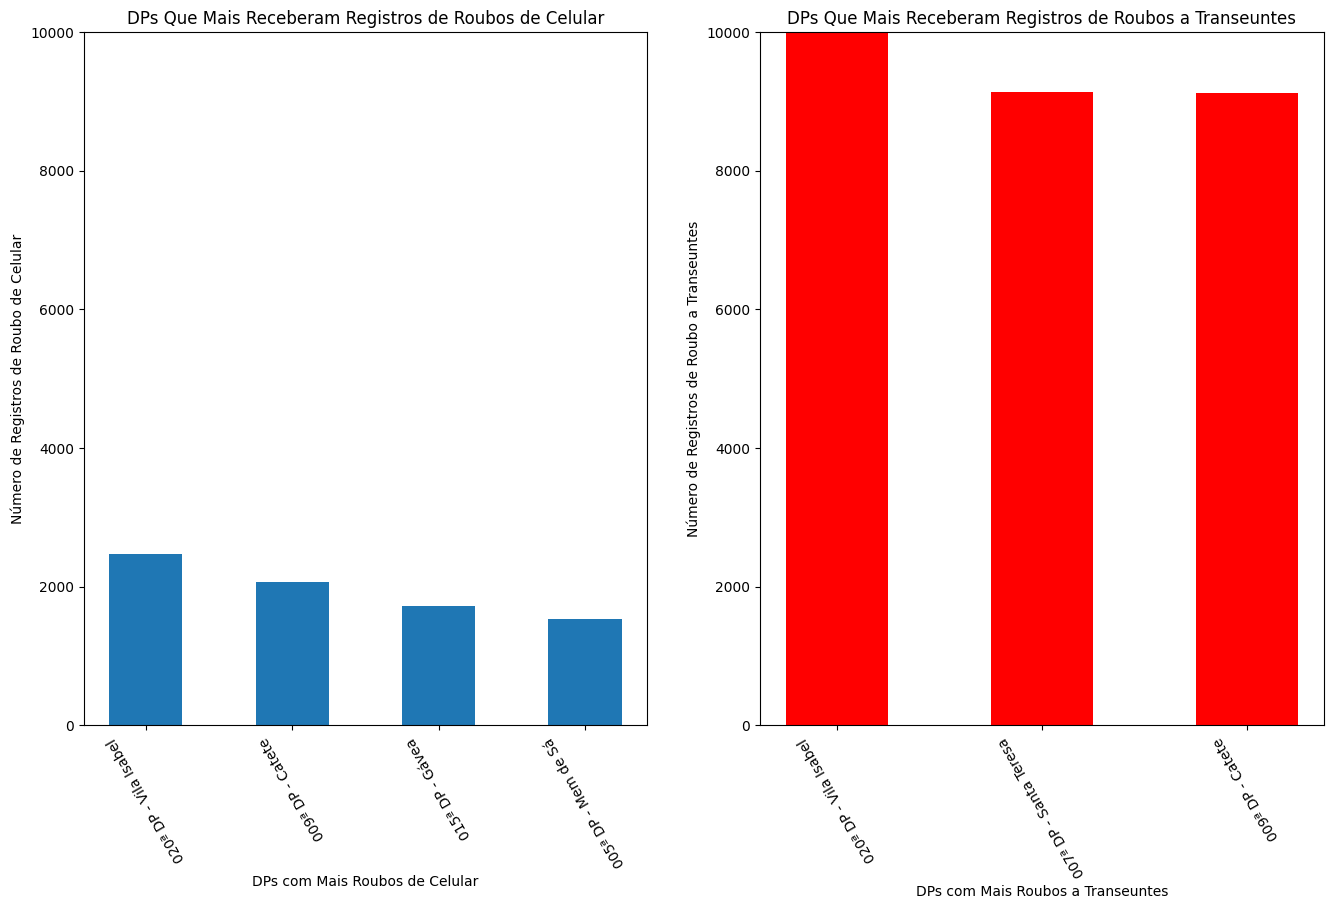

In [ ]:
plt.figure(figsize=(16, 9))

plt.subplot(1, 2, 1)
plt.bar(df_top3_roubo_celular_mes["nome"],df_top3_roubo_celular_mes["roubo_celular"], width=0.5)
plt.xticks(rotation=120)
plt.title("DPs Que Mais Receberam Registros de Roubos de Celular")
plt.xlabel("DPs com Mais Roubos de Celular")
plt.ylabel("Número de Registros de Roubo de Celular")
plt.ylim([0, 10000])


plt.subplot(1, 2, 2)
plt.bar(df_top3_roubo_transeunte_mes["nome"], df_top3_roubo_transeunte_mes["roubo_transeunte"], width=0.5, color="red")
plt.xticks(rotation=120)
plt.title("DPs Que Mais Receberam Registros de Roubos a Transeuntes")
plt.xlabel("DPs com Mais Roubos a Transeuntes")
plt.ylabel("Número de Registros de Roubo a Transeuntes")
plt.ylim([0, 10000])



plt.show()

Pelo gráfico suplra, pode-se observar as principais DPs do Top 3, com os dados mensais agregados. É relevante perceber como o Top 3, tanto de roubos de celular, quanto de roubos a transeuntes, está concentrado em pouquissímas DPs. Isso demonstra a recorrência desses crimes nessas regiões, constanto invariavelmente entre as Top 3 em vários meses (no caso dos roubos a transeuntes, para todos os meses, os crimes se localizam sempre nas DPS de Vila Isabel, Santa Teresa e Catete, para todos os meses do ano).